In [1]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42

import matplotlib.pyplot as plt
import scanpy as sc
import pandas as pd

import sys
sys.path.append('../../1_figure_CL_proof_of_concept/code/')
import utils_00 as gf_utils
large_data_dir = gf_utils.large_data_dir

color_palette = {}
color_palette['wt'] = 'blue'
color_palette['mutated'] = 'red'
color_palette['heterozygous'] = 'orange'


In [2]:
adata_dir = large_data_dir + 'MPN_WTA/MPN_1_BC007_genotyped.h5ad'
adata = sc.read_h5ad(adata_dir)
gf_utils.assign_genotypes(adata, min_counts=1, min_p=0.6)

TP53 c.920-1G>A 68


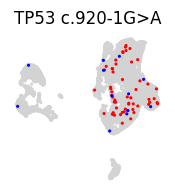

In [3]:
for variant in ['TP53 c.920-1G>A']:
    adata.obs[variant + '_call'] = adata.obsm['genotype_call'][variant] 
    print(variant, adata.obs[variant + '_call'].notna().sum()) ## check number of cells genotyped

    fig,ax = plt.subplots(figsize=(2,2))
    sc.pl.umap(adata, color = variant + '_call', palette=color_palette, frameon=False, ax=ax, show=False, legend_loc=None,title = variant[0:15], s=20)

    plt.savefig('../plots/' + variant + '_UMAP.pdf')


In [4]:
adata.obs['clone'] = pd.read_csv('../../6_figure_MPN_AML_phylogeny/output/clone_assignments.csv', index_col=0)['clone']

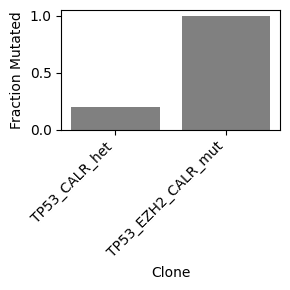

In [5]:
clones = []
fracs = []
for clone in adata.obs['clone'].unique():
    if pd.isna(clone):
        continue
    absolute_counts = adata[adata.obs['clone'] == clone].obs['TP53 c.920-1G>A_call'].notna().sum()
    if absolute_counts >= 5:
        genotype_counts = adata[adata.obs['clone'] == clone].obs['TP53 c.920-1G>A_call'].value_counts(normalize=True)
        if 'wt' in genotype_counts.index:
            frac_mutated = 1 - genotype_counts['wt']
            clones.append(clone)
            fracs.append(frac_mutated)
        elif 'mutated' in genotype_counts.index:
            frac_mutated = genotype_counts['mutated']
            clones.append(clone)
            fracs.append(frac_mutated)

fig, ax = plt.subplots(figsize=(3,3))
sorted_indices = [1, 0]
ax.bar(range(len(clones)), [fracs[i] for i in sorted_indices], color = 'grey')
ax.set_xticks(range(len(clones)))
ax.set_xticklabels([clones[i] for i in sorted_indices])
ax.set_ylabel('Fraction Mutated')
ax.set_xlabel('Clone')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.savefig('../plots/TP53_splice_by_clone.pdf')